In [10]:
import sys
# sys.path.append("D:/code/sire/install/python/release")
import sire

In [23]:
from os.path import abspath
import os
cs = sire.ControlServer.instance()
print(abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
cs.init()
simulator = sire.simulator(cs)
simulator.simDuration = 0.904
while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
  simulator.step(1, False)

print(sire.toXmlString(cs))
  # print("Simulation time", simulator.simTime())

d:\code\sire\demo\demo_python/sire_ball_free_fall.xml
<ControlServer>
    <Model __prop_name__="model" name="FreeFallModel" time="0.90400000000000069">
        <Environment __prop_name__="environment" gravity="{0,0,-9.81,0,0,0}"/>
        <VariablePoolElement __prop_name__="variable_pool">
            <MatrixVariable name="tool0_pe">{0,0,0,0,0,0}</MatrixVariable>
            <StringVariable name="tool0_pe_type">321</StringVariable>
            <MatrixVariable name="base_pe">{0,0,0,0,0,0}</MatrixVariable>
            <StringVariable name="base_pe_type">321</StringVariable>
        </VariablePoolElement>
        <PartPoolElement __prop_name__="part_pool">
            <Part name="ground" active="true" pe="{0,0,0,-0,0,-0}" vel="{0,0,0,0,0,0}" acc="{0,0,0,0,0,0}" inertia="{1,0,0,0,1,1,1,0,0,0}">
                <MarkerPoolElement __prop_name__="marker_pool">
                    <Marker name="joint_0_j" active="true" pe="{0,0,0,0,0,-0}"/>
                    <Marker name="ground" active="tru

In [20]:
model = cs.model()
displayInitJson = model.displayInitJson()
result = simulator.recordsToJson()

903 0.9030000000000007 0.0010000000000000009 [0.0, 0.0, 0.5000711999999865, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -8.84940000000009, 0.0, 0.0, 0.0] [0.0, 0.0, -9.8, -0.0, -0.0, -0.0] None
904 0.9040000000000007 0.0010000000000000009 [0.0, 0.0, 0.4912119999999864, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -8.85920000000009, 0.0, 0.0, 0.0] [0.0, 0.0, 79756.8514879971, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 79766.65148799711], 'contactWrench': [-0.0, 0.0, 79766.65148799711, 0.0, 0.0, 0.0], 'contact_point_pe': [0.0, 0.0, -0.004394000000006809, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': 0.0, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed': 0.0, 'slip_speed': 0.0}]


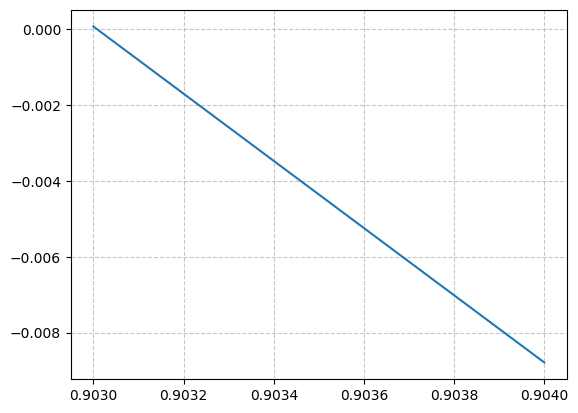

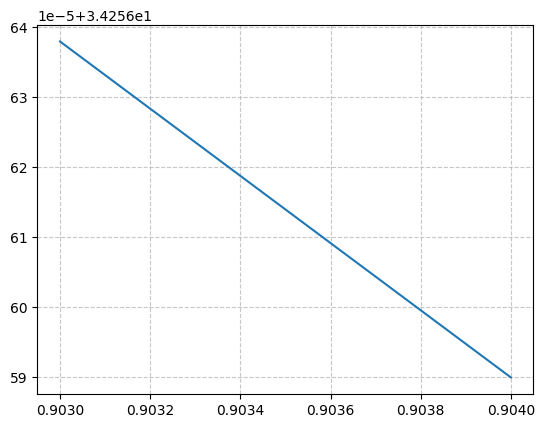

In [21]:
import matplotlib.pyplot as plt
import numpy as np
timeIndices = result['timeIndex']
contactInfo = result["contactInfo"]
partpq = result["partPq"]
partvs = result["partVs"]
partas = result["partAs"]
dts = result["dts"]
x = []
y = []
yv = []

lowerBound = sire.binarySearch(timeIndices, 0.903)
upperBound = sire.binarySearch(timeIndices, 10)

for i in range(lowerBound, upperBound + 1):
  print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  x.append(timeIndices[i])
  y.append(sire.pq2tfmatrix(partpq[i][1])[2, 3]-0.5)  # z position from transformation matrix
  yv.append(partvs[i][1][2])  # z velocity
plt.plot(x, y)
plt.grid(True, linestyle='--', alpha=0.7)
# plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data-1.pdf", format="pdf")
plt.show()

def calculate_energy(m, height, velocity, g):
    return m * g * height + 0.5 * m * velocity * velocity 

def replace_smaller_with_previous(lst, threshold):
    """
    将列表中所有小于threshold的值替换为前一个元素的值
    第一个元素没有前一个元素，保持不变
    """
    if not lst:  # 处理空列表
        return lst
    
    result = lst.copy()  # 创建列表的副本，避免修改原列表
    
    for i in range(1, len(result)):
        if result[i] < threshold:
            result[i] = result[i-1]
    
    return result

energyList = []
for i in range(lowerBound, upperBound + 1):
  energyList.append(calculate_energy(1.0, y[i - lowerBound]-0.5, yv[i - lowerBound], 9.8))

energy = replace_smaller_with_previous(energyList, -1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.plot(x, energy)
plt.show()

# def findMaxHeightAtRange(x, minTime, maxTime):
#   idx_t0 = min(range(len(x)), key=lambda i: abs(x[i] - minTime))
#   idx_t1 = min(range(len(x)), key=lambda i: abs(x[i] - maxTime))
#   height1Idx = np.argmax(y[idx_t0:idx_t1])
#   return (height1Idx+idx_t0, y[height1Idx+idx_t0])

# print(findMaxHeightAtRange(x, 1, 2))
# print(findMaxHeightAtRange(x, 2, 4))
# print(findMaxHeightAtRange(x, 4, 6))
# print(findMaxHeightAtRange(x, 6, 7))
# print(findMaxHeightAtRange(x, 8, 9))

In [28]:
currentIdx = 4015
print(currentIdx, timeIndices[currentIdx], dts[currentIdx], partpq[currentIdx][1], partvs[currentIdx][1], partas[currentIdx][1], contactInfo[currentIdx])
currentIdx = binarySearch(result["timeIndex"], 4.0052)
print(currentIdx, timeIndices[currentIdx], dts[currentIdx], partpq[currentIdx][1], partvs[currentIdx][1], partas[currentIdx][1], contactInfo[currentIdx])
currentIdx = binarySearch(result["timeIndex"], 4.00525)
print(currentIdx, timeIndices[currentIdx], dts[currentIdx], partpq[currentIdx][1], partvs[currentIdx][1], partas[currentIdx][1], contactInfo[currentIdx])


4015 0.4014999999999721 9.999999999998899e-05 [0.0, 0.0, 3.7099122400001296, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -3.9346999999994985, 0.0, 0.0, 0.0] [-0.0, -0.0, -9.8, 0.0, 0.0, -0.0] None
40054 4.005200000004004 9.999999999976694e-05 [0.0, 0.0, 3.75148766323579, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -3.8298400000091464, 0.0, 0.0, 0.0] [-0.0, -0.0, -9.8, 0.0, 0.0, -0.0] None
40055 4.005300000004004 9.999999999976694e-05 [0.0, 0.0, 3.75110458123579, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -3.830820000009144, 0.0, 0.0, 0.0] [-0.0, -0.0, -9.8, 0.0, 0.0, -0.0] None


In [29]:
# 4.190999999999734 [0.0, 0.0, 1.0000021810337338, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -0.002929150576415091, 0.0, 0.0, 0.0] [-0.0, -0.0, -9.8, 0.0, 0.0, -0.0] None
# 4.191999999999735 [0.0, 0.0, 0.9999894518831575, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -0.012729150576418364, 0.0, 0.0, 0.0] [0.0, 0.0, 87.49722059997538, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 97.29722059997538], 'contactWrench': [-0.0, 0.0, 97.29722059997538, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.49999472594157873, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': 0.0, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed': 0.0, 'slip_speed': 0.0}]
# 4.192999999999735 [0.0, 0.0, 0.9999914954560379, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, 0.00028451290447994385, 0.0, 0.0, 0.0] [0.0, 0.0, -9.8, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 0.0], 'contactWrench': [-0.0, 0.0, 0.0, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.49999574772801897, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': -2.1780204040311446e-07, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed': 0.0, 'slip_speed': 0.0}]
# 4.193999999999735 [0.0, 0.0, 0.9999819799689424, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -0.009515487095523328, 0.0, 0.0, 0.0] [0.0, 0.0, 895.3468337893621, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 905.1468337893621], 'contactWrench': [-0.0, 0.0, 905.1468337893621, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.4999909899844712, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': 9.515487095490549e-06, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed': 0.0, 'slip_speed': 0.0}]
